# Bitcoin Next-Day Price Prediction: Random Forest, Linear Regression and KNN

> **Summary:** Three regressors predict the next day's closing price from OHLCV data and moving averages (Jun 2019 – Aug 2022). With a random split, Linear Regression looks best (RMSE ≈ 1,128). Phase 4 re-tests with a **time-ordered split and a naive baseline** (tomorrow = today). No model beats the baseline, and direction accuracy is 48%. The prices behave like a random walk, so the honest result is that these features cannot forecast them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

file_path = "data/Bitcoin.csv"

#Read the data into a dataframe
df = pd.read_csv(file_path)

# Display basic info
print("Dataset Info:")
df.info()
print("First few rows:")
print(df.head())
print("\nLast few rows:")
print(df.tail())

# Check the shape of the dataset
print("\nShape of the dataset:", df.shape)

# EDA

# statistical summary for th variables
print("\nStatistical summary:")
print(df.describe())


# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


# Check for duplicates
print("\nDuplicates:", df.duplicated().sum())



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1151 entries, 0 to 1150
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1151 non-null   str    
 1   Open      1151 non-null   float64
 2   High      1151 non-null   float64
 3   Low       1151 non-null   float64
 4   Close     1151 non-null   float64
 5   Volume    1151 non-null   float64
 6   Currency  1151 non-null   str    
dtypes: float64(5), str(2)
memory usage: 63.1 KB
First few rows:
         Date          Open          High           Low         Close  \
0  2019-06-18   9128.269531   9149.763672   8988.606445   9062.045898   
1  2019-06-19   9068.174805   9277.677734   9051.094727   9271.459961   
2  2019-06-20   9271.567383   9573.689453   9209.416992   9519.200195   
3  2019-06-21   9526.833984  10130.935547   9526.833984  10127.998047   
4  2019-06-22  10151.890625  11171.013672  10083.189453  10719.981445   

     Volume Currency  
0  952850.0  

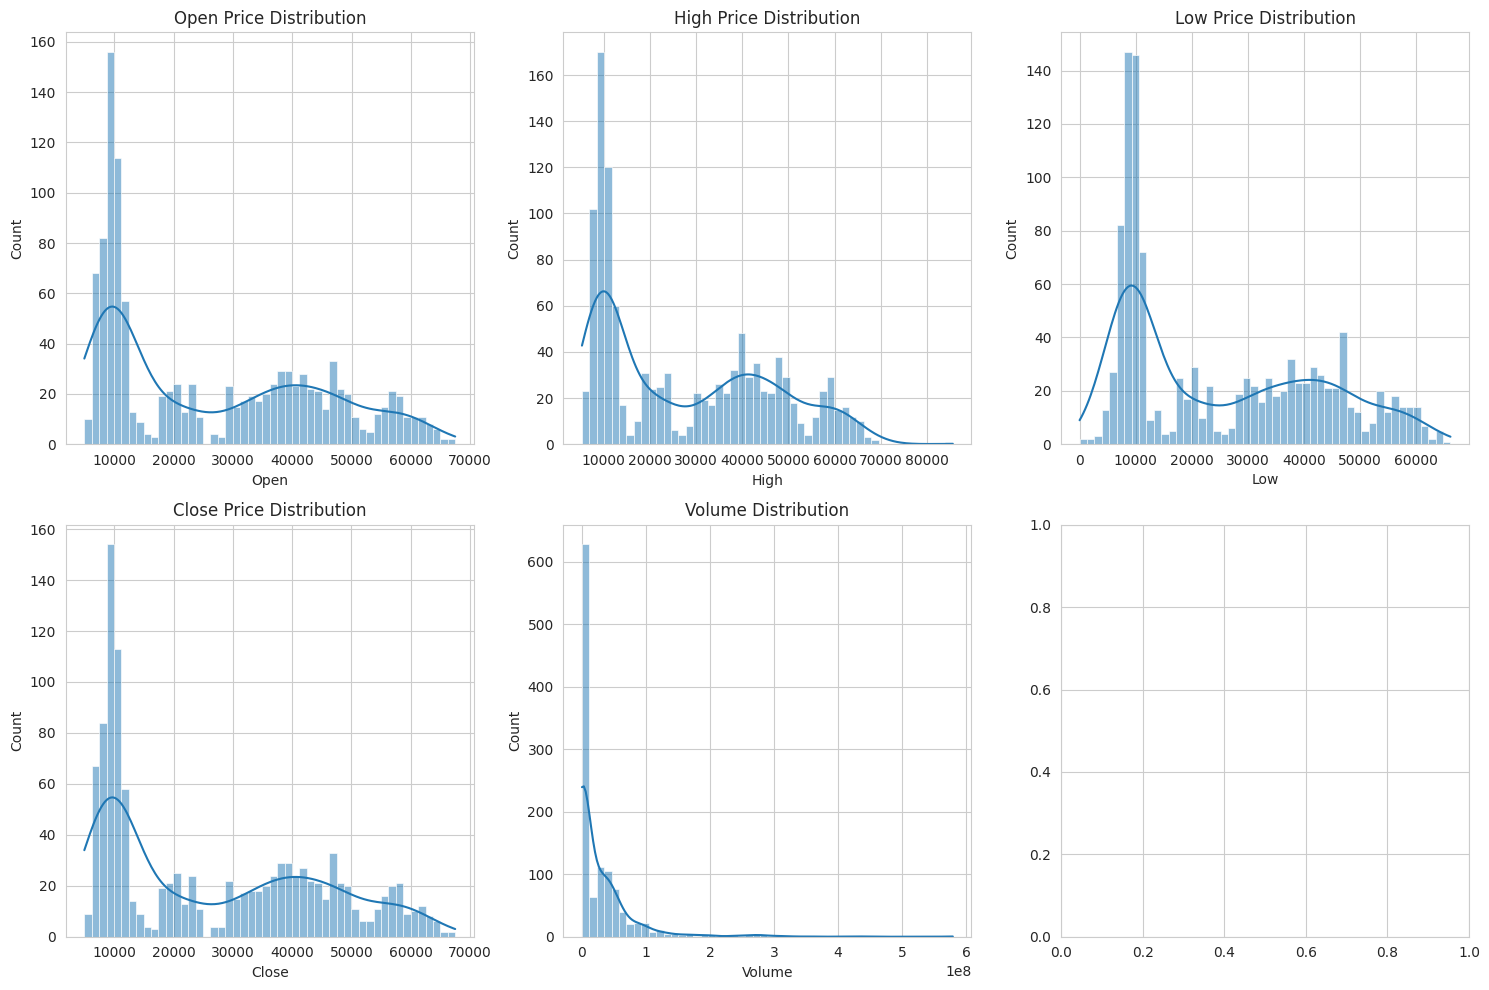

In [2]:
sns.set_style("whitegrid")

# Plot distributions of key features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.histplot(df['Open'], bins=50, kde=True, ax=axes[0, 0]).set(title="Open Price Distribution")
sns.histplot(df['High'], bins=50, kde=True, ax=axes[0, 1]).set(title="High Price Distribution")
sns.histplot(df['Low'], bins=50, kde=True, ax=axes[0, 2]).set(title="Low Price Distribution")
sns.histplot(df['Close'], bins=50, kde=True, ax=axes[1, 0]).set(title="Close Price Distribution")
sns.histplot(df['Volume'], bins=50, kde=True, ax=axes[1, 1]).set(title="Volume Distribution")

plt.tight_layout()
plt.show()

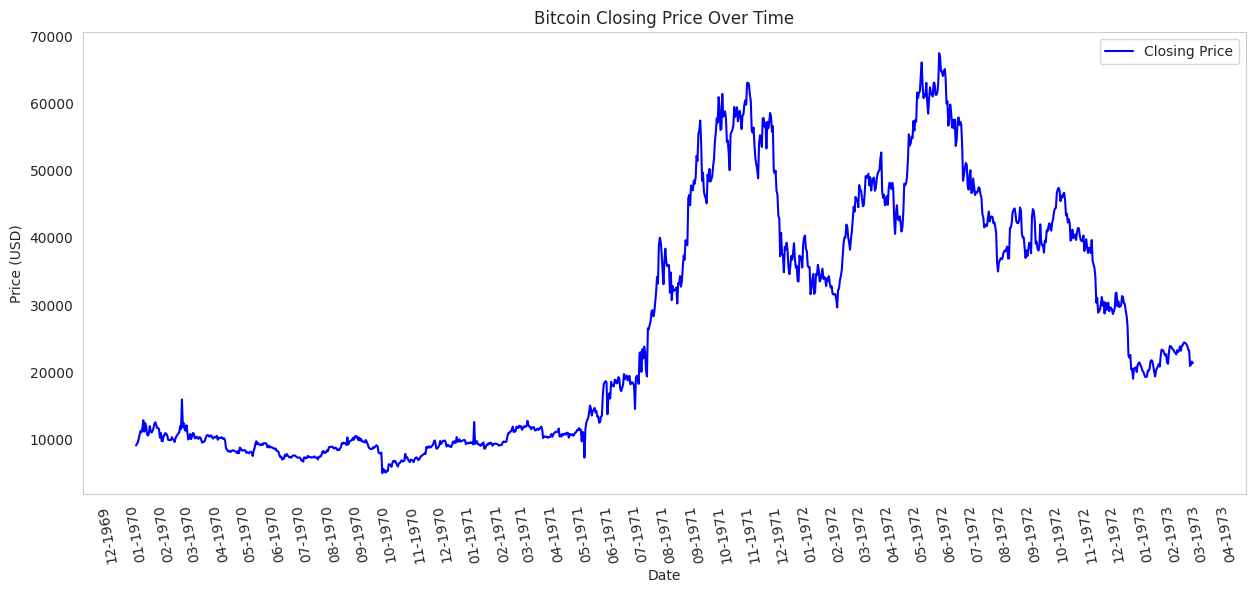

In [3]:
# Plot Closing Price Trend
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Close'], label="Closing Price", color='blue')

# Formatting the x-axis
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Bitcoin Closing Price Over Time")
plt.legend()
plt.grid()
plt.xticks(rotation=100)

# Set major x-axis locator to show fewer dates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%Y"))

plt.show()


In [4]:
# Target: next day's closing price
df = df.sort_values('Date').reset_index(drop=True)
df['future_close'] = df['Close'].shift(-1)
df = df.iloc[:-1].copy()

df.head()

,Date,Open,High,Low,Close,Volume,Currency,future_close
0,2019-06-18,9128.269531,9149.763672,8988.606445,9062.045898,952850.0,USD,9271.459961
1,2019-06-19,9068.174805,9277.677734,9051.094727,9271.459961,131077.0,USD,9519.200195
2,2019-06-20,9271.567383,9573.689453,9209.416992,9519.200195,83052.0,USD,10127.998047
3,2019-06-21,9526.833984,10130.935547,9526.833984,10127.998047,76227.0,USD,10719.981445
4,2019-06-22,10151.890625,11171.013672,10083.189453,10719.981445,84485.0,USD,11246.518555


In [5]:
# Price Change
df['price_change'] = df['Close'] - df['Open']

# Price Spread
df['price_spread'] = df['High'] - df['Low']

# Moving Averages
df['ma_7'] = df['Close'].rolling(window=7).mean()
df['ma_30'] = df['Close'].rolling(window=30).mean()

# Drop NaN values caused by moving averages
df.dropna(inplace=True)

df.head()


,Date,Open,High,Low,Close,Volume,Currency,future_close,price_change,price_spread,ma_7,ma_30
29,2019-07-17,9833.953125,10002.206055,9138.093750,9685.883789,444337.0,USD,10548.814453,-148.069336,864.112305,10771.386858,11076.655436
30,2019-07-18,9689.371094,10660.923828,9239.602539,10548.814453,321096.0,USD,10572.655273,859.443359,1421.321289,10612.605469,11126.214388
31,2019-07-19,10548.814453,10825.875000,10193.408203,10572.655273,122121.0,USD,10913.607422,23.840820,632.466797,10458.347656,11169.587565
32,2019-07-20,10597.679688,11314.213867,10265.417969,10913.607422,240565.0,USD,10792.991211,315.927734,1048.795898,10372.339565,11216.067806
33,2019-07-21,10913.607422,11229.353516,10204.167969,10792.991211,145889.0,USD,10556.007812,-120.616211,1025.185547,10451.065011,11238.234245


/tmp/ipykernel_593/3996106781.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


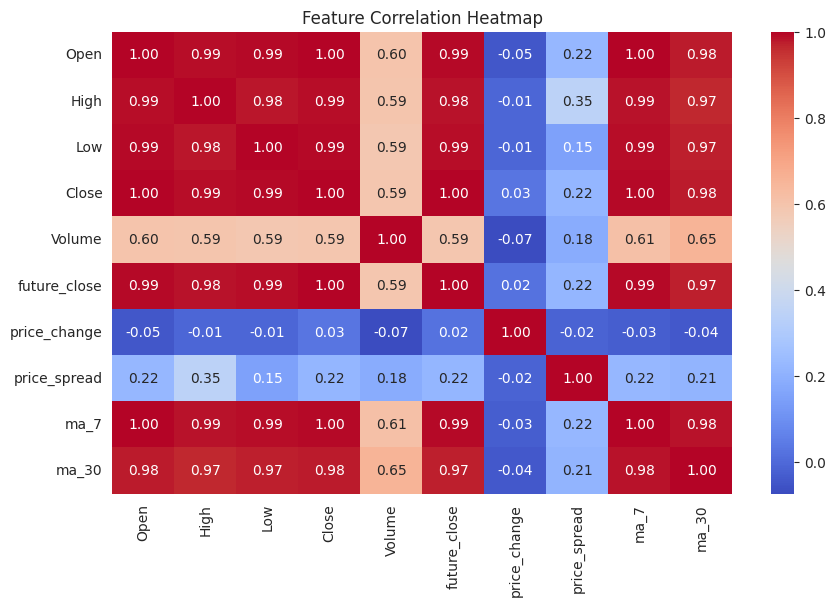

future_close    1.000000
Close           0.997120
Open            0.994822
ma_7            0.992824
Low             0.990567
High            0.984857
ma_30           0.972600
Volume          0.590787
price_spread    0.219800
price_change    0.022284
Name: future_close, dtype: float64


In [6]:
# Ensure 'date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Drop strings and non-numeric columns for correlation analysis
# The original code only dropped 'Date'. We also need to remove columns with 'USD'
for col in df.select_dtypes(include=['object']).columns:
    if df[col].astype(str).str.contains('USD').any():  # Check if column contains 'USD'
        df_numeric = df.drop(columns=[col, 'Date'])
        break  # Exit loop after finding and dropping the offending column
else:  # If no columns with 'USD' are found
    df_numeric = df.drop(columns=['Date'])

# Compute correlation
corr_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Sort features based on correlation with 'future_close'
corr_with_target = corr_matrix['future_close'].abs().sort_values(ascending=False)
print(corr_with_target)

In [7]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'price_change', 'price_spread', 'ma_7', 'ma_30']

# Define model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Perform RFE
selector = RFE(rf, n_features_to_select=5)
selector.fit(df[features], df['future_close'])

# Get selected features
selected_features = np.array(features)[selector.support_]
print("Selected Features:", selected_features)


Selected Features: ['Open' 'High' 'Low' 'Close' 'ma_30']


In [8]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# Fit Lasso model
lasso = Lasso(alpha=0.001, max_iter=50000)
lasso.fit(df[features], df['future_close'])

# Select important features
selected_lasso = df[features].columns[(lasso.coef_ != 0)]
print("LASSO Selected Features:", selected_lasso.tolist())


LASSO Selected Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'price_change', 'price_spread', 'ma_7', 'ma_30']


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.011e+09, tolerance: 3.633e+07
  model = cd_fast.enet_coordinate_descent(


## Phase 3: Model training (random split)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Features & Target
selected_features = ['Open', 'High', 'Low', 'Close', 'ma_30', 'Volume', 'price_spread', 'ma_7']
X = df[selected_features]
y = df['future_close']  # Target variable

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data split completed: Training size:", X_train.shape, "Testing size:", X_test.shape)


✅ Data split completed: Training size: (896, 8) Testing size: (225, 8)


In [10]:
# Initialize models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
lr_model = LinearRegression()
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train models
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)
lr_preds = lr_model.predict(X_test)
knn_preds = knn_model.predict(X_test)

# Evaluate RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_preds))

# Display results
print(f"📊 Model Performance (RMSE Lower = Better)")
print(f"🌲 Random Forest RMSE: {rf_rmse:.4f}")
print(f"📈 Linear Regression RMSE: {lr_rmse:.4f}")
print(f"🤖 KNN RMSE: {knn_rmse:.4f}")


📊 Model Performance (RMSE Lower = Better)
🌲 Random Forest RMSE: 1321.7977
📈 Linear Regression RMSE: 1128.3366
🤖 KNN RMSE: 7579.6141


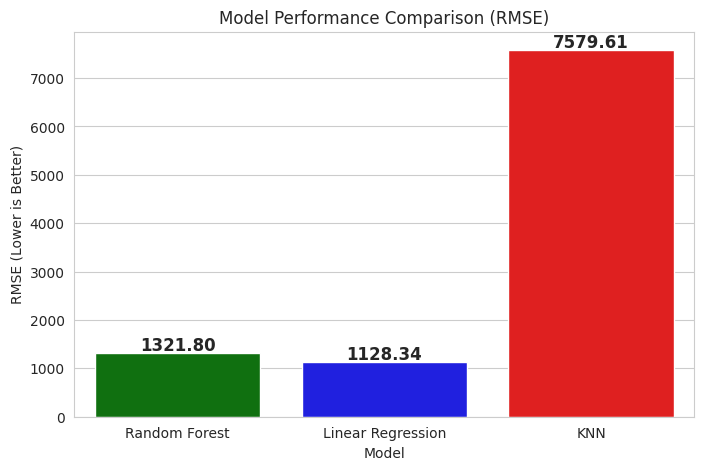

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# RMSE results
models = ['Random Forest', 'Linear Regression', 'KNN']
rmse_values = [rf_rmse, lr_rmse, knn_rmse]  # use computed values, not hard-coded ones

# Define color scheme
colors = ['green', 'blue', 'red']

# Create bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=rmse_values, hue=models, palette=colors, legend=False)

# labels and title
plt.ylabel('RMSE (Lower is Better)')
plt.xlabel('Model')
plt.title('Model Performance Comparison (RMSE)')
for i, v in enumerate(rmse_values):
    plt.text(i, v + 50, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.show()


## Phase 4: Honest evaluation (time-ordered split + naive baseline)

A random split lets the model train on days *after* the test days, which leaks future information. For forecasting, the test set must come after the training set. A model is only useful if it beats the naive forecast *tomorrow's close = today's close*.

In [12]:
cut = int(len(df) * 0.8)
train, test = df.iloc[:cut], df.iloc[cut:]
print('Train:', train['Date'].min().date(), '->', train['Date'].max().date())
print('Test: ', test['Date'].min().date(), '->', test['Date'].max().date())

def rmse(pred):
    return np.sqrt(mean_squared_error(test['future_close'], pred))

results = {'Naive (tomorrow = today)': rmse(test['Close'])}
for name, model in [('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
                    ('Linear Regression', LinearRegression()),
                    ('KNN', KNeighborsRegressor(n_neighbors=5))]:
    model.fit(train[selected_features], train['future_close'])
    results[name] = rmse(model.predict(test[selected_features]))

print(pd.Series(results, name='Test RMSE (USD)').round(0).sort_values())

lr = LinearRegression().fit(train[selected_features], train['future_close'])
pred = lr.predict(test[selected_features])
direction_acc = ((pred > test['Close']) == (test['future_close'] > test['Close'])).mean()
print(f'\nLinear Regression direction accuracy (up/down): {direction_acc:.0%}')

Train: 2019-07-17 -> 2022-01-08
Test:  2022-01-09 -> 2022-08-21


Naive (tomorrow = today)     1206.0
Linear Regression            1216.0
Random Forest                3288.0
KNN                         16699.0
Name: Test RMSE (USD), dtype: float64

Linear Regression direction accuracy (up/down): 48%


### Conclusion

- **No model beats the naive forecast.** Linear Regression is about equal to it, because it learns *tomorrow ≈ today's close*. Random Forest and KNN are worse: tree and neighbour models cannot predict prices outside the range they were trained on.
- **Direction accuracy is about 50%**, which is no better than a coin flip.
- The random-split RMSE in Phase 3 looked good only because consecutive prices are almost identical.

**Next steps:** predict returns instead of price levels; use walk-forward validation; add external drivers (volume shocks, on-chain data, macro news).